# FLUJO 3 — Resultados PSBP-FD
1. Lee trazas generadas por MATLAB
2. Diagnósticos de convergencia MCMC
3. Evaluación predictiva

## 1. Imports y rutas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import sys
import inspect
from pathlib import Path
from datetime import datetime
from scipy.io import loadmat
import pickle

# Módulos del paquete
from model_psbp_fd.pipelines import (
    FunctionalDomain,
    FARSimulator,
    gaussian_integral_kernel,
    build_integral_matrix,
)
from model_psbp_fd.functions_models import DataStandardizer
from model_psbp_fd.functions_models import FunctionalRepresentation
from model_psbp_fd.utils import get_project_root
from model_psbp_fd.models.psbp_fd_v2.functions.predict import PSBPPredictor

# Módulos de visualización
from model_psbp_fd.graphics import (
    plot_traces_bj, plot_traces_pj,
    plot_convergence_bj, plot_convergence_pj,
    plot_global_components, plot_active_clusters,
    plot_empirical_sample, plot_functional_mean,
    plot_functional_variance, plot_mean_and_variance,
    plot_fts_empirical, plot_fts_functional, plot_fts_comparison,
    plot_scatter_theta, plot_functional_comparison,
    plot_diagnostico_estandarizacion, plot_seleccion_basis,
    plot_fpca_scree, plot_fpca_correlacion_lag0, plot_rezagos_heatmap,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline


In [2]:
# ── Raíz del proyecto ─────────────────────────────────────────────────────
PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT : {PROJECT_ROOT}")

# ── Identificación del experimento ───────────────────────────────────────
BASENAME      = "modelo_unificado"
TT            = 3
SEED          = 4123
EXPERIMENT_ID = f"{BASENAME}_{TT}"
print(f"Experiment ID : {EXPERIMENT_ID}")
print(f"Seed (base)   : {SEED}")


PROJECT_ROOT : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1
Experiment ID : modelo_unificado_3
Seed (base)   : 4123


In [3]:
# ── Construcción de rutas ─────────────────────────────────────────────────
_REPORT_DIR   = PROJECT_ROOT / "reports"   / "simulaciones" / EXPERIMENT_ID
_ARTEFACT_DIR = PROJECT_ROOT / "artefact"  / "simulaciones" / EXPERIMENT_ID

PATHS = {
    "raw":          PROJECT_ROOT / "data" / "simulaciones" / "raw"       / EXPERIMENT_ID,
    "functional":   PROJECT_ROOT / "data" / "simulaciones" / "processed" / "functional" / EXPERIMENT_ID,
    "predict":      PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict"    / EXPERIMENT_ID,
    "out_report":   _REPORT_DIR,
    "out_artefact": _ARTEFACT_DIR,
}
for name, path in PATHS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"  {name:12s} → {path}")


  raw          → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\raw\modelo_unificado_3
  functional   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\modelo_unificado_3
  predict      → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\predict\modelo_unificado_3
  out_report   → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\reports\simulaciones\modelo_unificado_3
  out_artefact → C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\modelo_unificado_3


## 2. Lectura de datasets funcionales y manifest FPCA
Cargamos los datasets AR(p) generados por el pipeline de preprocesamiento,
el manifest con `component_idx` y `n_lags`, y la representación funcional ajustada.

In [4]:
# ── Manifest ─────────────────────────────────────────────────────────────
manifest_path = PATHS["functional"] / "datasets_manifest.json"
assert manifest_path.exists(), f"No se encontró: {manifest_path}"
with open(manifest_path) as f:
    manifest = json.load(f)

n_lags        = manifest["n_lags"]
COMPONENT_IDX = manifest["component_idx"]      # lista base-0
n_components  = len(COMPONENT_IDX)
cov_names     = manifest["cov_names"]

# [FIX] Contrato de escala: los datasets deben provenir del pipeline con
# scores estandarizados (02_01 §4.0). Si no, hay que regenerar los artefactos.
scores_scale = manifest.get("scores_scale", "raw")
assert scores_scale == "standardized_zscore_ddof0", (
    f"manifest['scores_scale']={scores_scale!r}: los datasets no usan scores "
    "estandarizados. Re-ejecuta 02_01_simulaciones (pipeline actualizado)."
)

print(f"n_components  : {n_components}")
print(f"n_lags        : {n_lags}")
print(f"COMPONENT_IDX : {COMPONENT_IDX}")
print(f"cov_names     : {cov_names}")
print(f"scores_scale  : {scores_scale}")


n_components  : 9
n_lags        : 2
COMPONENT_IDX : [0, 1, 2, 3, 4, 5, 6, 7, 8]
cov_names     : ['fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2', 'fpc_7_lag2', 'fpc_8_lag2', 'fpc_9_lag2']
scores_scale  : standardized_zscore_ddof0


In [5]:
# ── Cargar datasets AR(p) en dfs[k] ─────────────────────────────────────
# dfs[k] es el DataFrame del componente k (respuesta + predictores rezagados)
dfs = {}
for k in range(n_components):
    fpc_idx = COMPONENT_IDX[k] + 1          # base-1
    fpath   = PATHS["functional"] / f"dataset_fpc_{fpc_idx}.csv"
    assert fpath.exists(), f"No se encontró: {fpath}"
    dfs[k]  = pd.read_csv(fpath)
    print(f"  FPC {fpc_idx}  shape={dfs[k].shape}  cols={list(dfs[k].columns)}")


  FPC 1  shape=(118, 19)  cols=['fpc_1', 'fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2', 'fpc_7_lag2', 'fpc_8_lag2', 'fpc_9_lag2']
  FPC 2  shape=(118, 19)  cols=['fpc_2', 'fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2', 'fpc_7_lag2', 'fpc_8_lag2', 'fpc_9_lag2']
  FPC 3  shape=(118, 19)  cols=['fpc_3', 'fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag1', 'fpc_7_lag1', 'fpc_8_lag1', 'fpc_9_lag1', 'fpc_1_lag2', 'fpc_2_lag2', 'fpc_3_lag2', 'fpc_4_lag2', 'fpc_5_lag2', 'fpc_6_lag2', 'fpc_7_lag2', 'fpc_8_lag2', 'fpc_9_lag2']
  FPC 4  shape=(118, 19)  cols=['fpc_4', 'fpc_1_lag1', 'fpc_2_lag1', 'fpc_3_lag1', 'fpc_4_lag1', 'fpc_5_lag1', 'fpc_6_lag

In [6]:
# ── Cargar representación funcional ajustada (B-spline) ──────────────────────
# Serializada como .pkl en el notebook 02_01_simulaciones
fr_path = PATHS["functional"] / "functional_representation.pkl"
if fr_path.exists():
    with open(fr_path, "rb") as _f:
        fr = pickle.load(_f)
    print(f"✓ FunctionalRepresentation cargada: método={fr.method}, K={fr.n_basis}")
else:
    print(f"⚠ No se encontró functional_representation.pkl en {PATHS['functional']}")
    fr = None

# ── Cargar grilla del dominio ─────────────────────────────────────────────────
grid_path = PATHS["functional"] / "domain_grid.npy"
assert grid_path.exists(), f"No se encontró {grid_path} — ejecuta primero 02_01_simulaciones"
domain_grid = np.load(grid_path)
print(f"✓ Grilla cargada: {domain_grid.shape}")

# ── Cargar curvas (escala ORIGINAL) ───────────────────────────────────────────
# [FIX] Rediseño del pipeline: las curvas ya no se estandarizan; la referencia
# de comparación es X_curves (crudas). La estandarización vive en los scores.
X_curves_path = PATHS["functional"] / "X_curves.npy"
assert X_curves_path.exists(), (
    f"No se encontró {X_curves_path} — re-ejecuta 02_01_simulaciones "
    "(pipeline actualizado: crudo → B-spline → FPCA → scores estandarizados)."
)
X_curves = np.load(X_curves_path)
print(f"✓ X_curves cargado: {X_curves.shape}  (T, G) — escala original")

# ── Cargar estandarizador de SCORES ───────────────────────────────────────────
# [FIX] Necesario para des-estandarizar las predicciones del PSBP antes de
# reconstruir curvas.
scores_std_dir = PATHS["functional"] / "scores_standardizer"
assert (scores_std_dir / "standardizer_metadata.json").exists(), (
    f"No se encontró el estandarizador de scores en {scores_std_dir} — "
    "re-ejecuta 02_01_simulaciones §4.0."
)
scores_standardizer = DataStandardizer.load(scores_std_dir)

# ── Cargar artefactos FPCA desde disco ────────────────────────────────────────
# Psi_grid : (G, M) eigenfunciones en grilla   →  fpca_eigenfunctions.csv
# mu_grid  : (G,)   media funcional en grilla   →  fpca_mean.csv
# W        : (K, K) matriz de Gram L²           →  fpca_gram_W.csv
# B        : (K, M) coeficientes eigenfunciones →  fpca_coef_B.csv
# mu_theta : (K,)   media de coeficientes       →  fpca_mu_theta.csv
# THETA    : (T, K) coeficientes B-spline       →  theta.csv
# Phi      : (G, K) base B-spline en grilla     →  basis_phi.csv
# SCORES   : (T, M) scores FPCA observados (escala ORIGINAL) → fpca_scores.csv
fpca_files = {
    "Psi_grid": PATHS["functional"] / "fpca_eigenfunctions.csv",
    "mu_grid":  PATHS["functional"] / "fpca_mean.csv",
    "W":        PATHS["functional"] / "fpca_gram_W.csv",
    "B":        PATHS["functional"] / "fpca_coef_B.csv",
    "mu_theta": PATHS["functional"] / "fpca_mu_theta.csv",
    "THETA":    PATHS["functional"] / "theta.csv",
    "Phi":      PATHS["functional"] / "basis_phi.csv",
    "SCORES":   PATHS["functional"] / "fpca_scores.csv",
}

fpca_arrays = {}
fpca_available = True
for name, path in fpca_files.items():
    if path.exists():
        fpca_arrays[name] = np.loadtxt(path, delimiter=",")
        print(f"✓ {name:10s}: {fpca_arrays[name].shape}")
    else:
        print(f"⚠ No se encontró {path.name} — ejecuta primero 02_01_simulaciones")
        fpca_available = False

if fpca_available:
    Psi_grid = fpca_arrays["Psi_grid"]   # (G, M)
    mu_grid  = fpca_arrays["mu_grid"]    # (G,)
    W        = fpca_arrays["W"]          # (K, K)
    B        = fpca_arrays["B"]          # (K, M)
    mu_theta = fpca_arrays["mu_theta"]   # (K,)
    THETA    = fpca_arrays["THETA"]      # (T, K)
    Phi      = fpca_arrays["Phi"]        # (G, K)
    SCORES   = fpca_arrays["SCORES"]     # (T, M) — escala original (var = λ_m)

fpca_meta_path = PATHS["functional"] / "fpca_meta.json"
if fpca_meta_path.exists():
    with open(fpca_meta_path) as _f:
        fpca_meta = json.load(_f)
    M_fpca = fpca_meta["M"]
    K      = fpca_meta["K"]
    print(f"✓ fpca_meta: M={M_fpca}, K={K}, var_explained={fpca_meta['var_explained']:.4%}")
else:
    fpca_meta = {}
    M_fpca    = Psi_grid.shape[1] if fpca_available else None
    K         = THETA.shape[1]    if fpca_available else None

# ── Operadores de reconstrucción ──────────────────────────────────────────────
# Ambos operan sobre scores en escala ORIGINAL (des-estandarizar antes).
#
# (1) FPCA → curva en grilla:  X̂(t) = μ(t) + Ξ · Ψᵀ
def reconstruct_from_scores(S_hat):
    """scores FPCA escala original (T, M) → curvas en grilla (T, G)."""
    S_hat = np.atleast_2d(np.asarray(S_hat, dtype=float))
    return mu_grid[None, :] + S_hat @ Psi_grid.T

# (2) scores FPCA → coeficientes B-spline:
#     [FIX] Antes se usaba pinv(W @ B), la inversa por la izquierda de norma
#     euclídea mínima, que NO es la proyección FPCA cuando W ≠ I (base no
#     ortonormal) y producía curvas distintas a reconstruct_from_scores.
#     Por ortonormalidad en métrica L² (Bᵀ W B = I), la inversa correcta del
#     truncamiento FPCA es Bᵀ:  Θ̂ = μ_θ + Ξ Bᵀ, y entonces
#     Θ̂ Φᵀ ≡ μ + Ξ Ψᵀ exactamente (Ψ = Φ B).
def scores_to_theta(S_hat):
    """scores FPCA escala original (T, M) → coeficientes B-spline (T, K)."""
    S_hat = np.atleast_2d(np.asarray(S_hat, dtype=float))
    return S_hat @ B.T + mu_theta[None, :]

# ── Sanidad: ambos operadores deben producir LA MISMA curva ───────────────────
if fpca_available:
    _ortho_err = np.abs(B.T @ W @ B - np.eye(M_fpca)).max()
    _S_chk  = SCORES[:5]
    _eq_err = np.abs(reconstruct_from_scores(_S_chk)
                     - scores_to_theta(_S_chk) @ Phi.T).max()
    print(f"[sanidad] max|BᵀWB − I|                  : {_ortho_err:.2e}  (≈ 0)")
    print(f"[sanidad] max|FPCA−reconstr. vía B-spline|: {_eq_err:.2e}  (≈ 0)")
    assert _eq_err < 1e-8, (
        "Las dos rutas de reconstrucción divergen: revisa B, W, mu_theta, Phi."
    )


✓ FunctionalRepresentation cargada: método=bspline, K=29
✓ Grilla cargada: (200,)
✓ X_curves cargado: (120, 200)  (T, G) — escala original
✓ Standardizer cargado desde: C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\data\simulaciones\processed\functional\modelo_unificado_3\scores_standardizer
✓ Psi_grid  : (200, 9)
✓ mu_grid   : (200,)
✓ W         : (29, 29)
✓ B         : (29, 9)
✓ mu_theta  : (29,)
✓ THETA     : (120, 29)
✓ Phi       : (200, 29)
✓ SCORES    : (120, 9)
✓ fpca_meta: M=9, K=29, var_explained=90.5241%
[sanidad] max|BᵀWB − I|                  : 2.22e-15  (≈ 0)
[sanidad] max|FPCA−reconstr. vía B-spline|: 1.33e-15  (≈ 0)


## 3. Lectura de trazas MATLAB
Configuramos el patrón de nombre, definimos el loader y ensamblamos
`models_chains[k][c]` con el adaptador `MatlabTraceModel`.

In [7]:
# ── Configuración de trazas ───────────────────────────────────────────────
TRACE_DIR = PATHS["out_artefact"]
N_ITER    = 3   # número de iteraciones del experimento (réplicas por componente)
                 # Ajusta este valor según cuántas cadenas haya generado MATLAB

# Patrón de nombre: chain_fpc_<fpc_idx>_iter<tt>.mat
def trace_path(fpc_idx: int, tt: int) -> Path:
    return TRACE_DIR / f"chain_fpc_{fpc_idx}_iter{tt:02d}.mat"

print(f"TRACE_DIR : {TRACE_DIR}")
print(f"N_ITER    : {N_ITER}  (cadenas por componente)")
print(f"Ejemplo   : {trace_path(1, 1).name}")


TRACE_DIR : C:\Users\56jua\Desktop\git_tesis\bayesian_non_parametrics-1\artefact\simulaciones\modelo_unificado_3
N_ITER    : 3  (cadenas por componente)
Ejemplo   : chain_fpc_1_iter01.mat


In [8]:
# ── Loader: .mat → dict de trazas ────────────────────────────────────────
def load_trace_mat(path: Path) -> tuple:
    """
    Carga un archivo .mat generado por psbp_train y devuelve
    (traces_dict, burn, feature_names_list).
    """
    m      = loadmat(str(path))
    keys2d = ["betajhout", "beta0hout", "tauhout", "alphahout",
              "psijhout", "Gammajhout", "gammajhout", "pijout",
              "wjout", "osumout", "inEout"]
    traces = {k: np.asarray(m[k], dtype=np.float64) for k in keys2d}
    for k in ["muout", "N1out", "Nout"]:
        traces[k] = np.asarray(m[k], dtype=np.float64).ravel()
    burn  = int(np.asarray(m["burn"]).ravel()[0])
    feat  = str(np.atleast_1d(m["feature_names"]).ravel()[0]).split(",")
    return traces, burn, feat


# ── Adaptador: trazas MATLAB → objeto compatible con funciones de visualización
class MatlabTraceModel:
    """
    Expone .traces y .feature_names_ tal como los esperan las funciones
    plot_* del paquete, y delega predicción en PSBPPredictor.
    """
    def __init__(self, traces: dict, burn: int, feature_names: list):
        self.traces         = traces
        self.feature_names_ = list(feature_names)
        self.burn           = int(burn)
        self.n_features_    = int(traces["betajhout"].shape[2])
        # PSBPPredictor es agnóstico a la escala (no desestandariza)
        self.predictor_     = PSBPPredictor(traces=traces, burn=burn)

    def _design(self, df: pd.DataFrame) -> np.ndarray:
        """Construye matriz de diseño con intercepto desde un DataFrame."""
        Xp = np.asarray(df.iloc[:, 1:], dtype=float)
        return np.hstack([np.ones((Xp.shape[0], 1)), Xp])

    def predict(self, df: pd.DataFrame, return_std: bool = False):
        return self.predictor_.predict(self._design(df), return_std=return_std)

    def inclusion_probs(self, as_series: bool = False):
        incl = self.predictor_.inclusion_probs()
        if as_series:
            return pd.Series(incl, index=self.feature_names_, name="inclusion_prob")
        return incl

    def rmse(self, df: pd.DataFrame, y_obs=None) -> float:
        if y_obs is None:
            y_obs = np.asarray(df.iloc[:, 0], dtype=float)
        return self.predictor_.rmse(self._design(df), y_obs)


In [9]:
# ── Ensamblar models_chains[k][c] ────────────────────────────────────────
# [FIX] Antes los .mat faltantes se omitían en silencio, dejando claves no
# contiguas que rompían range(n_components) aguas abajo (KeyError) o, peor,
# desalineaban componentes. Ahora la carga es estricta: si falta un archivo
# se aborta con la lista completa de faltantes.
missing = []
for k in range(n_components):
    fpc_idx = COMPONENT_IDX[k] + 1
    for c in range(N_ITER):
        p_ = trace_path(fpc_idx, c + 1)
        if not p_.exists():
            missing.append(p_.name)
assert not missing, (
    f"Faltan {len(missing)} trazas en {TRACE_DIR}: {missing}. "
    "Ejecuta psbp_fd_iteracion.m antes de continuar."
)

models_chains = {k: {} for k in range(n_components)}
_meta_seen = set()

for k in range(n_components):
    fpc_idx = COMPONENT_IDX[k] + 1
    for c in range(N_ITER):
        tt   = c + 1
        path = trace_path(fpc_idx, tt)
        traces, burn, feat = load_trace_mat(path)

        # Verificar consistencia con las columnas del dataset
        expected = list(dfs[k].columns[1:])
        assert feat == expected, (
            f"[k={k} tt={tt}] feature_names del .mat ≠ columnas del dataset:\n"
            f"  mat={feat}\n  dfs={expected}\n"
            "Las trazas no corresponden a los datasets actuales; regenera."
        )

        models_chains[k][c] = MatlabTraceModel(traces, burn, feat)
        nsim = traces["betajhout"].shape[0]
        N    = traces["betajhout"].shape[1]
        _meta_seen.add((nsim, N, burn))
        print(f"  FPC {fpc_idx}  iter{tt:02d}  ← {path.name}  "
              f"(p={len(feat)}, N={N}, nsim={nsim}, burn={burn})")

# [FIX] Homogeneidad de configuración entre archivos (antes TRACE_META tomaba
# silenciosamente los valores del último archivo cargado).
assert len(_meta_seen) == 1, (
    f"Configuraciones MCMC heterogéneas entre trazas: {_meta_seen}. "
    "Mezclar nsim/N/burn distintos invalida el análisis conjunto."
)
nsim, N, BURN = next(iter(_meta_seen))
n_chains_loaded = N_ITER

TRACE_META = {
    "nsim":     int(nsim),
    "burn":     int(BURN),
    "N":        int(N),
    "n_chains": n_chains_loaded,
    "source":   "matlab",
}
print(f"\n✓ models_chains listo: {len(models_chains)} componente(s) × "
      f"{n_chains_loaded} cadena(s)  BURN={BURN}")


  FPC 1  iter01  ← chain_fpc_1_iter01.mat  (p=18, N=20, nsim=2000, burn=500)
  FPC 1  iter02  ← chain_fpc_1_iter02.mat  (p=18, N=20, nsim=2000, burn=500)
  FPC 1  iter03  ← chain_fpc_1_iter03.mat  (p=18, N=20, nsim=2000, burn=500)
  FPC 2  iter01  ← chain_fpc_2_iter01.mat  (p=18, N=20, nsim=2000, burn=500)
  FPC 2  iter02  ← chain_fpc_2_iter02.mat  (p=18, N=20, nsim=2000, burn=500)
  FPC 2  iter03  ← chain_fpc_2_iter03.mat  (p=18, N=20, nsim=2000, burn=500)
  FPC 3  iter01  ← chain_fpc_3_iter01.mat  (p=18, N=20, nsim=2000, burn=500)
  FPC 3  iter02  ← chain_fpc_3_iter02.mat  (p=18, N=20, nsim=2000, burn=500)
  FPC 3  iter03  ← chain_fpc_3_iter03.mat  (p=18, N=20, nsim=2000, burn=500)
  FPC 4  iter01  ← chain_fpc_4_iter01.mat  (p=18, N=20, nsim=2000, burn=500)
  FPC 4  iter02  ← chain_fpc_4_iter02.mat  (p=18, N=20, nsim=2000, burn=500)
  FPC 4  iter03  ← chain_fpc_4_iter03.mat  (p=18, N=20, nsim=2000, burn=500)
  FPC 5  iter01  ← chain_fpc_5_iter01.mat  (p=18, N=20, nsim=2000, burn=500)

## 4. Diagnósticos de convergencia MCMC

| Estadístico | Referencia | Lectura |
|---|---|---|
| ACF(lag) | autocorrelación residual | cerca de 0 ⇒ buena mezcla |
| ESS | Geyer (1992) | ESS ≳ 400 ideal |
| Geweke z | test z entre segmentos | \|z\| < 2 ⇒ no rechazo |
| Gelman-Rubin R̂ | Brooks-Gelman (1998) | R̂ < 1.1 ⇒ convergencia |


### 4.1 Componentes globales (μ, N₁, α, τ, β₀, p_j)

In [ ]:
for k in models_chains:
    fig = plot_global_components(
        models_chains, k, BURN, n_chains_loaded,
        title_prefix = f"FPC {k+1}",
        save_path    = str(PATHS["out_report"] / f"10_global_comp_k{k+1}.png"),
    )
    plt.show()


In [ ]:
for k in models_chains:
    fig = plot_active_clusters(
        models_chains, k, BURN, n_chains_loaded,
        title_prefix = f"FPC {k+1}",
        save_path    = str(PATHS["out_report"] / f"11_clusters_activos_k{k+1}.png"),
    )
    plt.show()


### 4.2 Convergencia completa (traza | ACF | posterior + métricas)

In [ ]:
all_diag_bj = {}
for k in models_chains:
    feat = models_chains[k][0].feature_names_
    fig, diag = plot_convergence_bj(
        models_chains, k, BURN, n_chains_loaded,
        feature_names = feat,
        title_prefix  = f"FPC {k+1}",
        save_path     = str(PATHS["out_report"] / f"14_convergencia_bj_k{k+1}.png"),
    )
    all_diag_bj[k] = diag
    plt.show()


In [ ]:
all_diag_pj = {}
for k in models_chains:
    feat = models_chains[k][0].feature_names_
    fig, diag = plot_convergence_pj(
        models_chains, k, BURN, n_chains_loaded,
        feature_names = feat,
        title_prefix  = f"FPC {k+1}",
        save_path     = str(PATHS["out_report"] / f"15_convergencia_pj_k{k+1}.png"),
    )
    all_diag_pj[k] = diag
    plt.show()


In [ ]:
# ── Tabla resumen de diagnósticos ────────────────────────────────────────
diag_records = []
for k in models_chains:
    for rec in all_diag_bj.get(k, []):
        diag_records.append({"componente": k+1, "param": "beta_j", **rec})
    for rec in all_diag_pj.get(k, []):
        diag_records.append({"componente": k+1, "param": "p_j",    **rec})

diag_df = pd.DataFrame(diag_records)
if not diag_df.empty:
    display(
        diag_df.style
        .format({"ess_min": "{:.1f}", "ess_mean": "{:.1f}",
                 "geweke_max": "{:+.2f}", "rhat": "{:.3f}"})
        .background_gradient(subset=["rhat"],    cmap="RdYlGn_r", vmin=1.0, vmax=1.2)
        .background_gradient(subset=["ess_min"], cmap="RdYlGn",   vmin=0,   vmax=500)
        .map(lambda v: "font-weight:bold;color:#c0392b" if v is False else "",
             subset=["converge"])
        .set_caption("Diagnósticos MCMC por variable")
    )
else:
    print("No hay datos de diagnóstico disponibles.")


## 5. Evaluación predictiva **(in-sample)**

Las métricas de esta sección se calculan sobre los mismos datos usados para
entrenar (ajuste in-sample, no pronóstico fuera de muestra). Las respuestas
y predicciones están en escala de **scores estandarizados**; para reconstruir
curvas (§5.3–5.4) las predicciones se des-estandarizan con el
`scores_standardizer` persistido por `02_01`.

In [10]:
# ── Predicciones por componente (in-sample) ───────────────────────────────
# [FIX] Antes se usaba solo la cadena c=0, descartando 2/3 del posterior.
# Ahora se agrupan las cadenas: con cadenas de igual longitud post burn-in,
# la media posterior agrupada es el promedio de las medias por cadena.
eval_results = {}

for k in models_chains:
    df_k  = dfs[k]
    y_obs = np.asarray(df_k.iloc[:, 0], dtype=float)        # escala estandarizada

    chain_ids    = sorted(models_chains[k].keys())
    y_hat_chains = np.column_stack(
        [models_chains[k][c].predict(df_k) for c in chain_ids]
    )                                                        # (T_eff, n_chains)
    y_hat = y_hat_chains.mean(axis=1)                        # posterior agrupado

    incl_chains = pd.concat(
        [models_chains[k][c].inclusion_probs(as_series=True) for c in chain_ids],
        axis=1,
    )
    incl_named = incl_chains.mean(axis=1).rename("inclusion_prob")

    rmse_k = float(np.sqrt(np.mean((y_hat - y_obs) ** 2)))

    # ── [FIX] Check de contrato MATLAB ↔ Python: inEout vs PSBPPredictor ──
    # MATLAB guarda E[y|x] in-sample por iteración (inEout). Su media post
    # burn-in debe aproximar la predicción del predictor por cadena. No son
    # idénticas (inE usa los β PREVIOS a la actualización de esa iteración,
    # y las trazas se guardan en single), pero una divergencia grande
    # indicaría un bug en el sampler o en el predictor.
    for c in chain_ids:
        m_c      = models_chains[k][c]
        inE_mean = m_c.traces["inEout"][m_c.burn:].mean(axis=0)   # (T_eff,)
        y_hat_c  = y_hat_chains[:, c]
        diff     = float(np.abs(inE_mean - y_hat_c).max())
        corr     = float(np.corrcoef(inE_mean, y_hat_c)[0, 1])
        flag     = "" if corr > 0.999 else "  ⚠ revisar contrato sampler↔predictor"
        print(f"  FPC {COMPONENT_IDX[k]+1} cad{c+1}: "
              f"|inEout−predict|max={diff:.4f}  corr={corr:.5f}{flag}")

    eval_results[k] = {
        "y_obs":        y_obs,            # scores ESTANDARIZADOS
        "y_hat":        y_hat,            # scores ESTANDARIZADOS (pooled)
        "y_hat_chains": y_hat_chains,
        "incl_named":   incl_named,
        "rmse":         rmse_k,           # escala estandarizada, in-sample
    }
    print(f"  FPC {COMPONENT_IDX[k]+1}  RMSE(in-sample, std, pooled)={rmse_k:.6f}")

print("\n✓ eval_results construido (posterior agrupado sobre "
      f"{n_chains_loaded} cadenas)")


  FPC 1 cad1: |inEout−predict|max=0.0001  corr=1.00000
  FPC 1 cad2: |inEout−predict|max=0.0002  corr=1.00000
  FPC 1 cad3: |inEout−predict|max=0.0003  corr=1.00000
  FPC 1  RMSE(in-sample, std, pooled)=0.105762
  FPC 2 cad1: |inEout−predict|max=0.0001  corr=1.00000
  FPC 2 cad2: |inEout−predict|max=0.0003  corr=1.00000
  FPC 2 cad3: |inEout−predict|max=0.0005  corr=1.00000
  FPC 2  RMSE(in-sample, std, pooled)=0.674707
  FPC 3 cad1: |inEout−predict|max=0.0002  corr=1.00000
  FPC 3 cad2: |inEout−predict|max=0.0005  corr=1.00000
  FPC 3 cad3: |inEout−predict|max=0.0006  corr=1.00000
  FPC 3  RMSE(in-sample, std, pooled)=0.752395
  FPC 4 cad1: |inEout−predict|max=0.0005  corr=1.00000
  FPC 4 cad2: |inEout−predict|max=0.0005  corr=1.00000
  FPC 4 cad3: |inEout−predict|max=0.0002  corr=1.00000
  FPC 4  RMSE(in-sample, std, pooled)=0.821942
  FPC 5 cad1: |inEout−predict|max=0.0000  corr=1.00000
  FPC 5 cad2: |inEout−predict|max=0.0007  corr=1.00000
  FPC 5 cad3: |inEout−predict|max=0.0003  

### 5.1 Scatter ξ observado vs ξ predicho (scores FPCA estandarizados, in-sample)

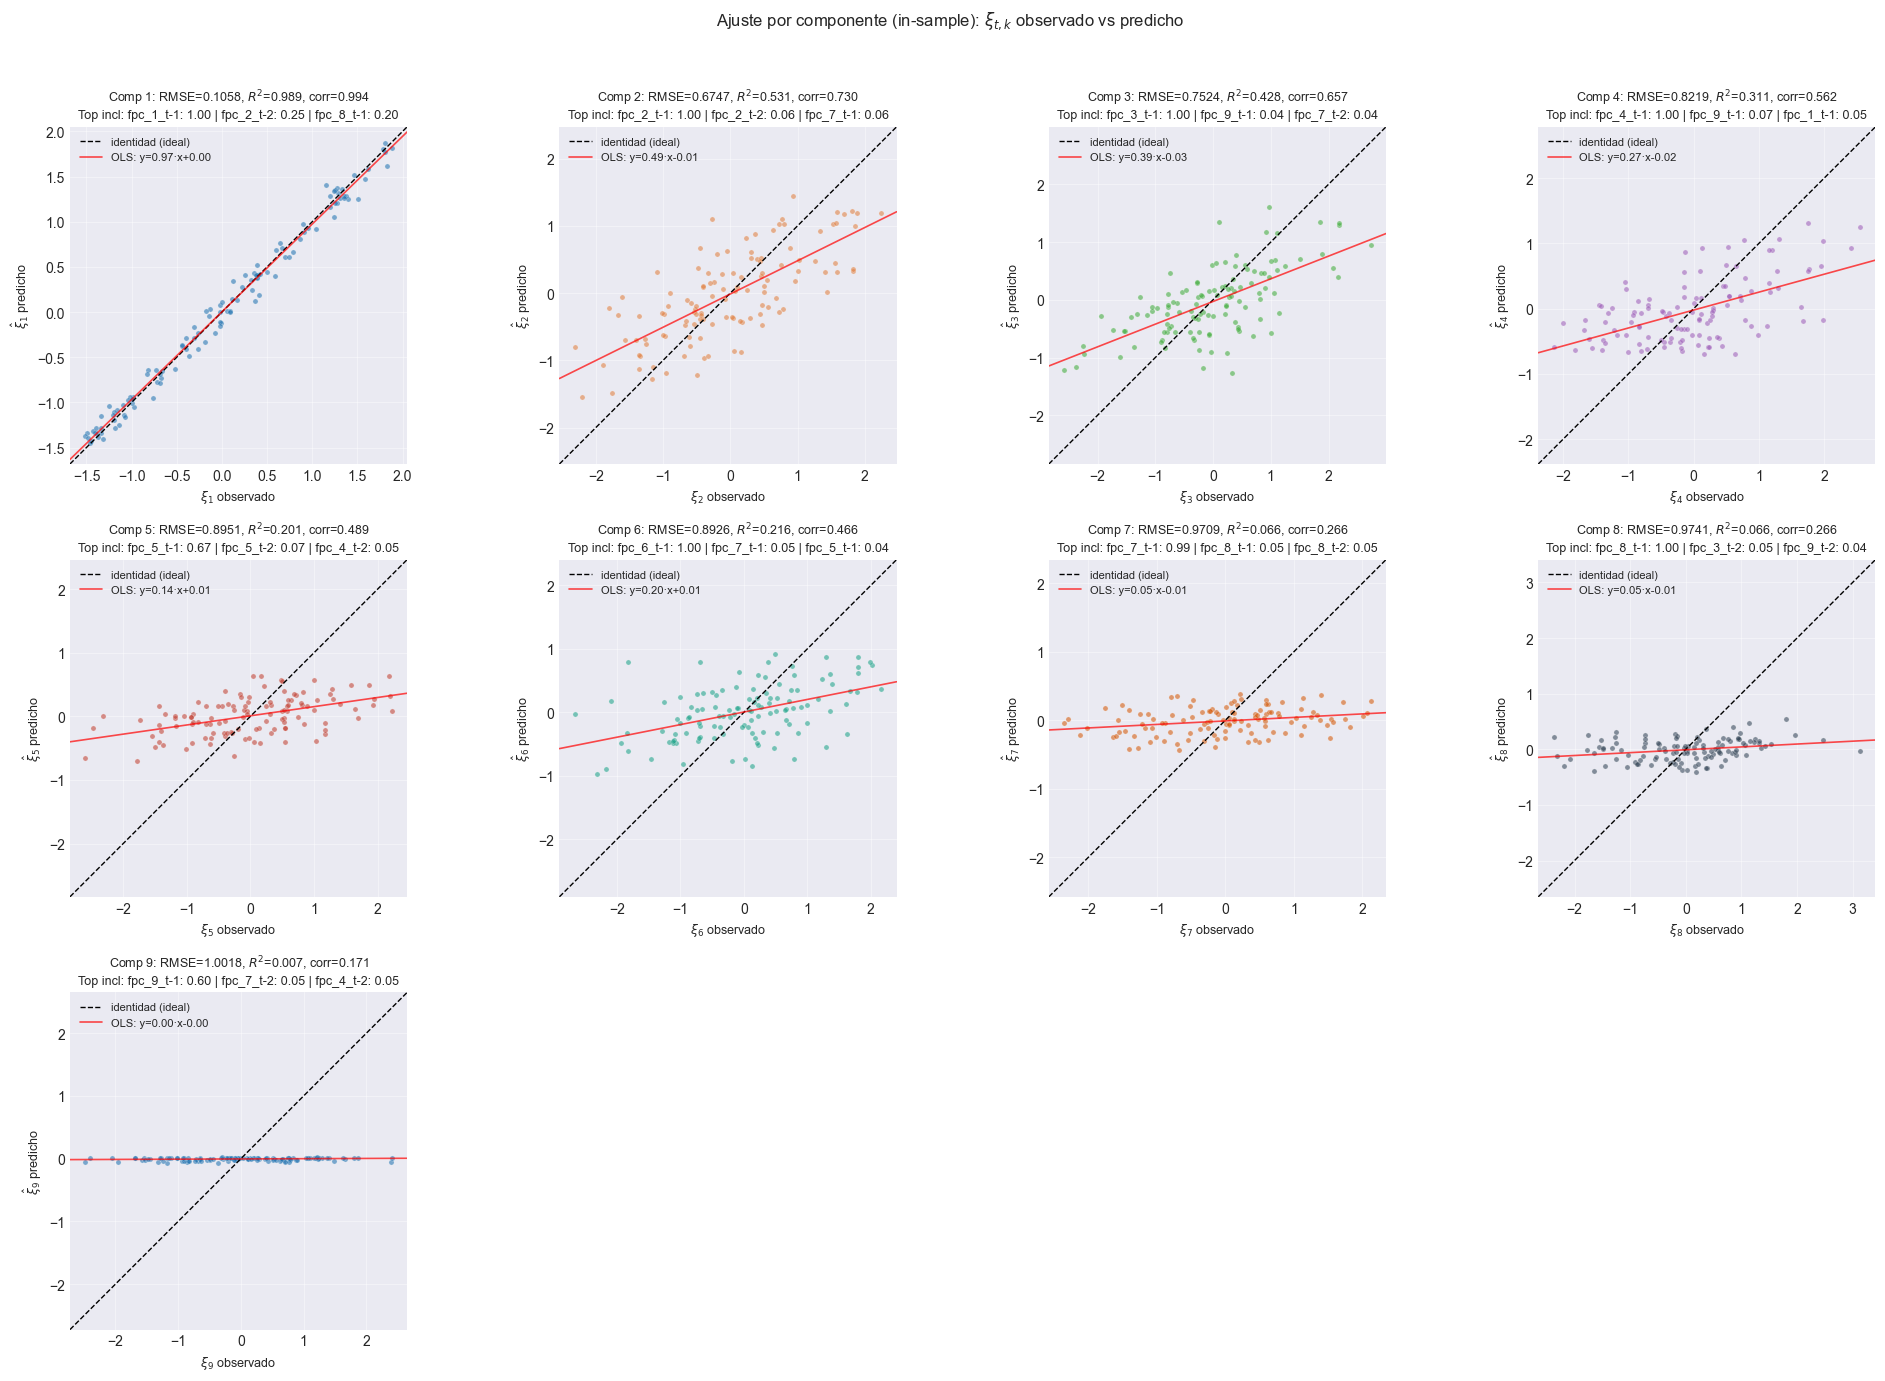

In [11]:
fig = plot_scatter_theta(
    eval_results,
    n_components = len(models_chains),
    save_path    = str(PATHS["out_report"] / "20_scatter_theta.png"),
)
plt.show()


### 5.2 Probabilidades de inclusión por variable

In [12]:
# Tabla de inclusión por componente y variable
incl_df = pd.DataFrame({
    f"FPC {COMPONENT_IDX[k]+1}": eval_results[k]["incl_named"]
    for k in models_chains
})
display(
    incl_df.style
    .background_gradient(cmap="RdYlGn", vmin=0, vmax=1)
    .format("{:.3f}")
    .set_caption("P(γ_j = 1 | data) — Probabilidades de inclusión por variable y componente")
)


,FPC 1,FPC 2,FPC 3,FPC 4,FPC 5,FPC 6,FPC 7,FPC 8,FPC 9
fpc_1_lag1,1.000,0.054,0.036,0.054,0.046,0.026,0.027,0.029,0.038
fpc_2_lag1,0.016,1.000,0.033,0.046,0.037,0.026,0.041,0.040,0.039
fpc_3_lag1,0.027,0.050,1.000,0.035,0.049,0.035,0.047,0.019,0.041
fpc_4_lag1,0.072,0.037,0.036,1.000,0.043,0.040,0.038,0.033,0.052
fpc_5_lag1,0.023,0.039,0.022,0.030,0.667,0.040,0.036,0.038,0.033
fpc_6_lag1,0.021,0.047,0.037,0.034,0.042,1.000,0.044,0.025,0.050
fpc_7_lag1,0.022,0.057,0.028,0.048,0.045,0.054,0.987,0.036,0.042
fpc_8_lag1,0.197,0.050,0.033,0.042,0.039,0.032,0.050,0.998,0.044
fpc_9_lag1,0.018,0.043,0.038,0.068,0.034,0.032,0.043,0.034,0.600
fpc_1_lag2,0.023,0.054,0.037,0.036,0.033,0.024,0.044,0.031,0.033


### 5.3 Reconstrucción funcional

Las predicciones (scores estandarizados) se **des-estandarizan** y se
reconstruyen curvas por las dos rutas equivalentes — FPCA
($\hat X = \mu + \hat\Xi\,\Psi^\top$) y B-spline
($\hat\Theta = \mu_\theta + \hat\Xi\,B^\top$, luego
$\hat X = \hat\Theta\,\Phi^\top$) — que coinciden exactamente por
ortonormalidad en métrica $L^2$ ($B^\top W B = I$). La comparación es
contra las curvas originales `X_curves`.

[sanidad] max|ruta B-spline − ruta FPCA| : 1.78e-15  (≈ 0)
RMSE representación (truncamiento FPCA) : 0.394861
RMSE predicción (modelo PSBP)           : 0.506814
MISE L² predicción                      : 0.255461
RMSE funcional (√MISE)                  : 0.505431
── Métricas de reconstrucción (escala de X_true) ──
  RMSE representación : 0.394861   NRMSE=0.335
  RMSE modelo         : 0.318045   NRMSE=0.270
  RMSE total          : 0.506814   NRMSE=0.430
  Ratio modelo/total  : 0.628


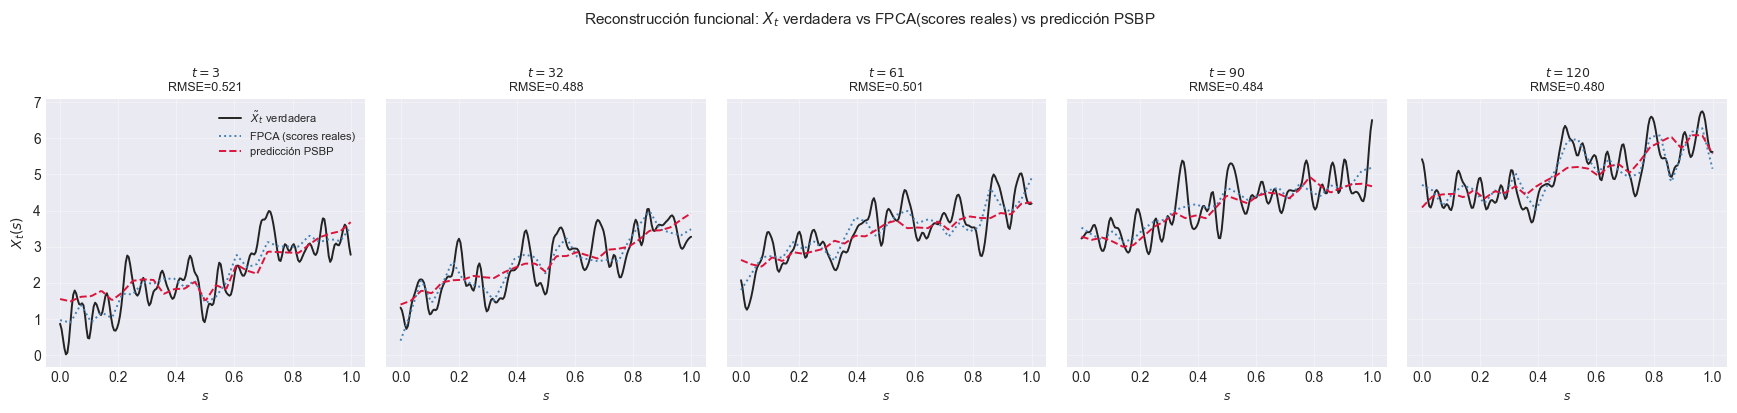


── Métricas de reconstrucción (in-sample) ──────────────────
  rmse_repr            : 0.394861
  rmse_model           : 0.318045
  rmse_total           : 0.506814
  nrmse_repr           : 0.334687
  nrmse_model          : 0.269578
  nrmse_total          : 0.429580


In [13]:
if fpca_available and fr is not None:
    # ── Scores verdaderos en ambas escalas ────────────────────────────────────
    SCORES_STD_true = scores_standardizer.transform(SCORES)   # (T, M) estandarizados

    # ── Matrices de scores efectivos (T_eff, M) ───────────────────────────────
    # Predicciones en escala ESTANDARIZADA (la del modelo); componentes no
    # modeladas (si las hubiera) conservan el score observado.
    SCORES_STD_true_eff = SCORES_STD_true[n_lags:]            # (T_eff, M)
    SCORES_STD_pred_eff = SCORES_STD_true_eff.copy()
    for k, idx in enumerate(COMPONENT_IDX):
        SCORES_STD_pred_eff[:, idx] = eval_results[k]["y_hat"]

    # ── [FIX] Des-estandarizar ANTES de reconstruir curvas ────────────────────
    SCORES_true_eff = SCORES[n_lags:]                                       # (T_eff, M) escala original
    SCORES_pred_eff = scores_standardizer.inverse_transform(SCORES_STD_pred_eff)

    # ── Reconstrucción en grilla (ruta FPCA) ──────────────────────────────────
    X_fpca_obs  = reconstruct_from_scores(SCORES_true_eff)    # (T_eff, G)
    X_fpca_pred = reconstruct_from_scores(SCORES_pred_eff)    # (T_eff, G)
    X_true_eff  = X_curves[n_lags:, :]                        # (T_eff, G) original alineada

    # ── Ruta B-spline (vía Θ̂ = μ_θ + Ξ̂ Bᵀ) — debe coincidir con la FPCA ──────
    THETA_pred_eff = scores_to_theta(SCORES_pred_eff)         # (T_eff, K)
    X_bspline_pred = THETA_pred_eff @ Phi.T                   # (T_eff, G)
    _eq = float(np.abs(X_bspline_pred - X_fpca_pred).max())
    print(f"[sanidad] max|ruta B-spline − ruta FPCA| : {_eq:.2e}  (≈ 0)")
    assert _eq < 1e-8, "Las rutas de reconstrucción divergen tras el fix de Bᵀ."
    # [FIX] Se elimina la doble familia de métricas "B-spline vs FPCA": tras
    # corregir scores_to_theta (Bᵀ en vez de pinv(W·B)) ambas rutas son la
    # misma curva; reportar dos RMSE distintos era un artefacto.

    # ── Métricas (in-sample, escala original de las curvas) ──────────────────
    rmse_fpca_repr = float(np.sqrt(np.mean((X_true_eff - X_fpca_obs ) ** 2)))
    rmse_fpca_pred = float(np.sqrt(np.mean((X_true_eff - X_fpca_pred) ** 2)))
    mise_pred      = float(np.trapezoid(
        np.mean((X_fpca_pred - X_true_eff) ** 2, axis=0), domain_grid
    ))
    print(f"RMSE representación (truncamiento FPCA) : {rmse_fpca_repr:.6f}")
    print(f"RMSE predicción (modelo PSBP)           : {rmse_fpca_pred:.6f}")
    print(f"MISE L² predicción                      : {mise_pred:.6f}")
    print(f"RMSE funcional (√MISE)                  : {np.sqrt(mise_pred):.6f}")

    # ── Visualización: plot_functional_comparison ─────────────────────────────
    # La función apila eval_results[k] en columnas 0..n-1 y reconstruye con
    # fr.reconstruct; el proxy aplica la inversa FPCA. Requiere que las
    # columnas coincidan con el orden FPCA completo.
    if COMPONENT_IDX == list(range(M_fpca)):
        class _FPCAProxy:
            """Proxy con .reconstruct(S) = inversa FPCA (scores escala original)."""
            def reconstruct(self, S):
                return reconstruct_from_scores(S)

        # [FIX] eval_results está en escala estandarizada; el proxy reconstruye
        # desde escala original → se pasa una vista des-estandarizada.
        eval_results_orig = {
            k: {
                "y_obs": SCORES_true_eff[:, idx],
                "y_hat": SCORES_pred_eff[:, idx],
                "incl_named": eval_results[k]["incl_named"],
            }
            for k, idx in enumerate(COMPONENT_IDX)
        }

        fig, metrics = plot_functional_comparison(
            eval_results  = eval_results_orig,
            fr            = _FPCAProxy(),
            domain_grid   = domain_grid,
            X_true        = X_curves,
            n_components  = n_components,
            n_lags        = n_lags,
            n_snapshots   = 5,
            # [FIX] etiqueta veraz: la capa intermedia es FPCA(scores reales)
            repr_label    = "FPCA (scores reales)",
            title         = (r"Reconstrucción funcional: $X_t$ verdadera vs "
                             r"FPCA(scores reales) vs predicción PSBP"),
            save_path     = str(PATHS["out_report"] / "21_reconstruccion_funcional_fpca.png"),
        )
        plt.show()

        print("\n── Métricas de reconstrucción (in-sample) ──────────────────")
        for key, val in metrics.items():
            print(f"  {key:20s} : {val:.6f}")
    else:
        print("⚠ COMPONENT_IDX no cubre las M componentes en orden FPCA; "
              "se omite plot_functional_comparison (apilado por columnas inválido).")
else:
    print("⚠ fpca_available=False o fr=None — omitiendo reconstrucción funcional.")


### 5.4 Serie de tiempo funcional: predicha vs verdadera

(A) capa B-spline real (`fr`) y (B) capa FPCA. En ambos casos la predicción
PSBP se muestra des-estandarizada y alineada con offset `n_lags`.

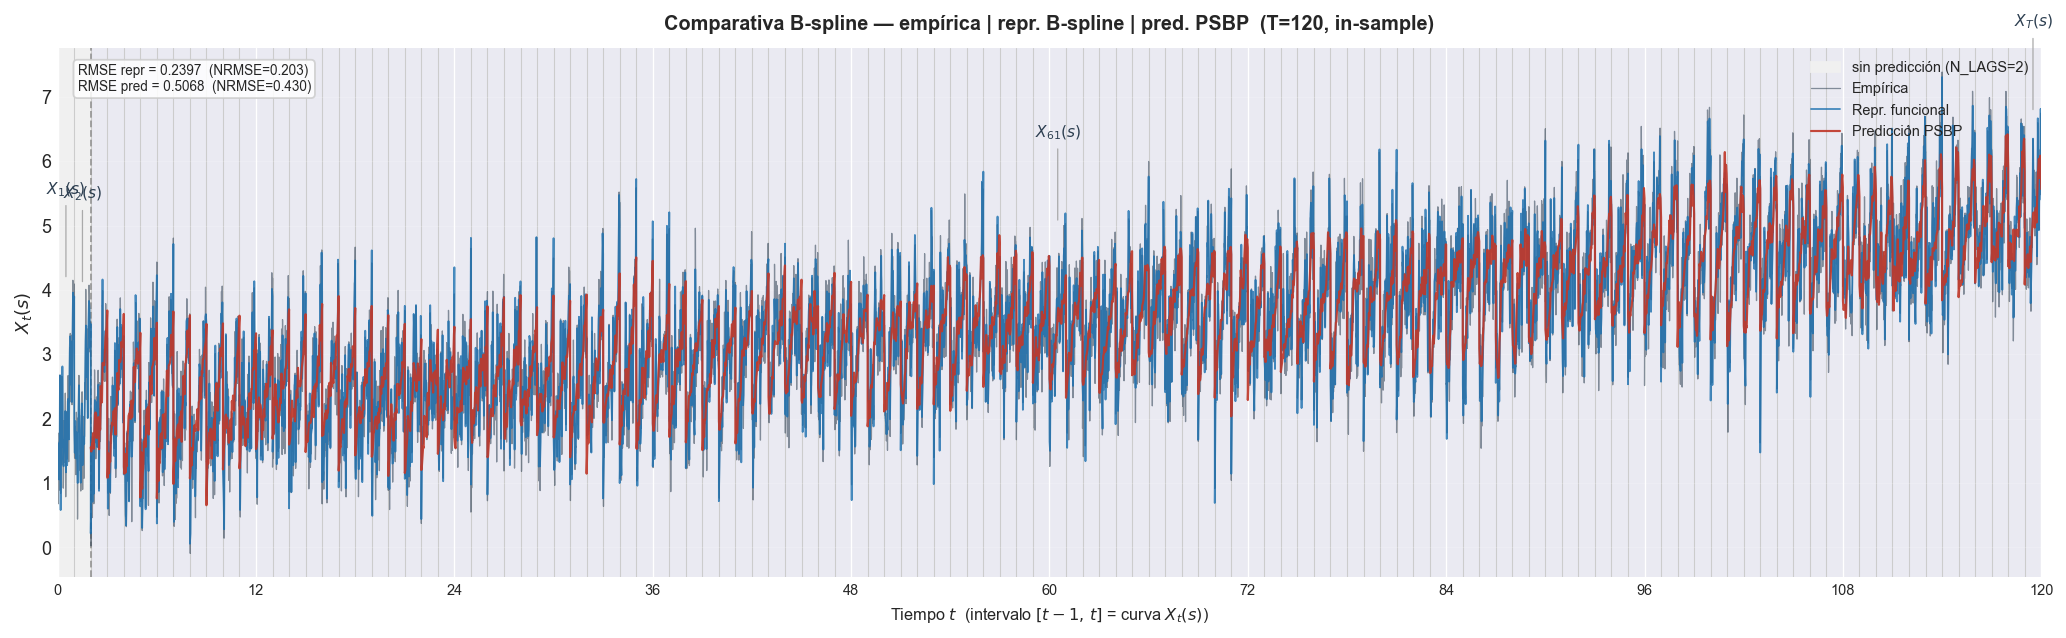

── Métricas B-spline (in-sample) ───────────────────────────────────
  rmse_repr            : 0.239689
  rmse_pred            : 0.506814
  nrmse_repr           : 0.203162
  nrmse_pred           : 0.429580


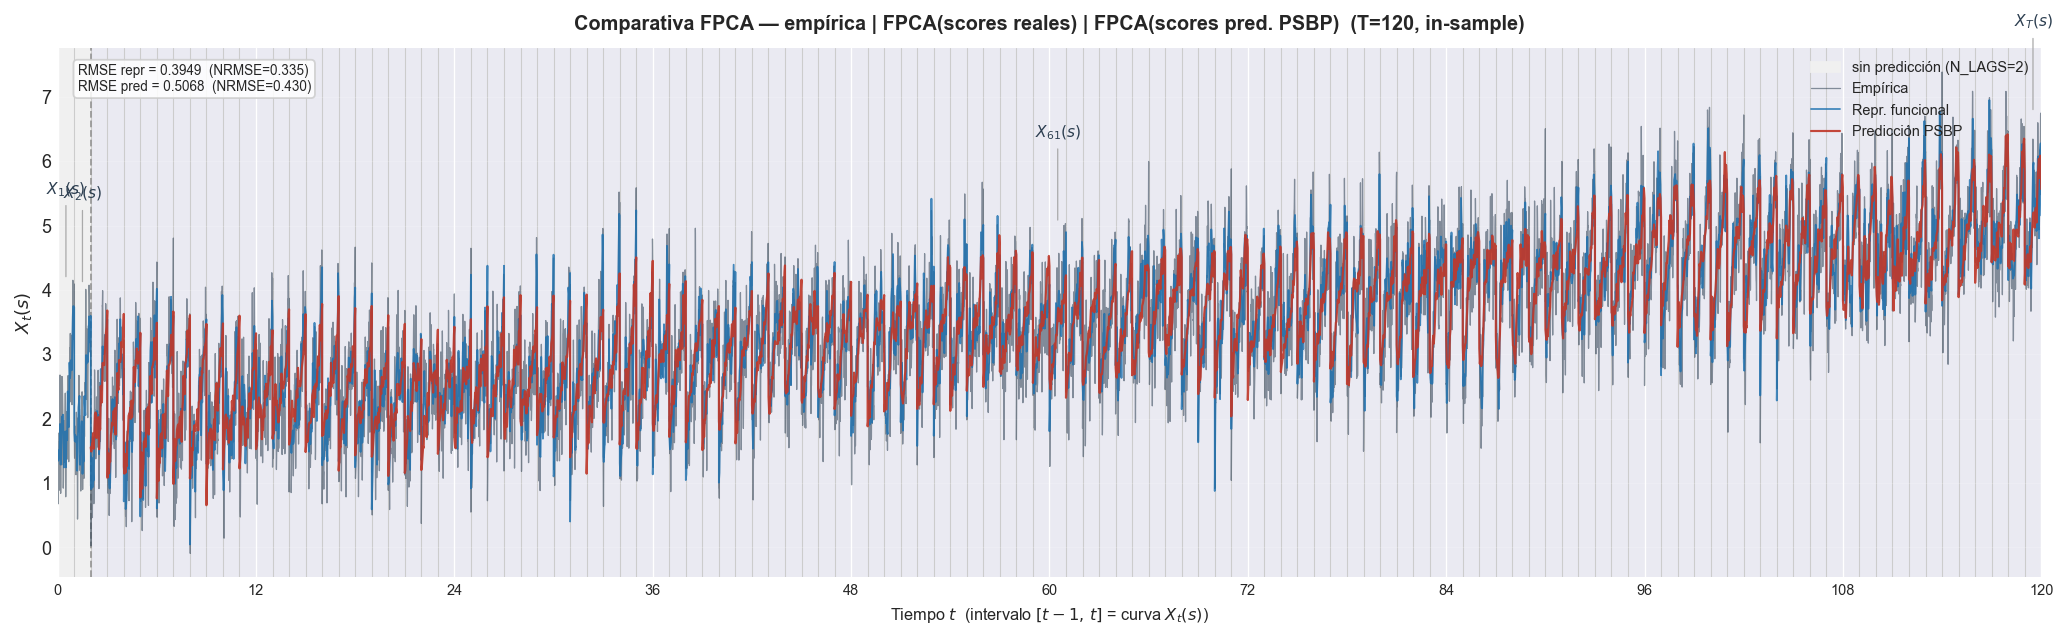

── Métricas FPCA (in-sample) ────────────────────────────────────────
  rmse_repr            : 0.394861
  rmse_pred            : 0.506814
  nrmse_repr           : 0.334687
  nrmse_pred           : 0.429580


In [14]:
if fpca_available and fr is not None:

    # ── (A) Serie de tiempo en espacio B-spline ───────────────────────────────
    # Comparación: empírica | repr. B-spline (fr real) | pred. PSBP→B-spline
    # X_bspline_pred : (T_eff, G) construida en §5.3 desde scores predichos
    # des-estandarizados (idéntica a X_fpca_pred por el assert de §5.3).
    fig_bspline, metrics_bspline = plot_fts_comparison(
        X           = X_curves,        # (T, G) empírica completa (escala original)
        grid        = domain_grid,
        fr          = fr,              # FunctionalRepresentation B-spline real
        X_pred_repr = X_bspline_pred,  # (T_eff, G)
        n_lags      = n_lags,
        title       = (
            "Comparativa B-spline — empírica | repr. B-spline | pred. PSBP"
            f"  (T={X_curves.shape[0]}, in-sample)"
        ),
        save_path   = str(PATHS["out_report"] / "22a_fts_comparacion_bspline.png"),
    )
    plt.show()

    print("── Métricas B-spline (in-sample) ───────────────────────────────────")
    for key, val in metrics_bspline.items():
        print(f"  {key:20s} : {val:.6f}")

    # ── (B) Serie de tiempo en espacio FPCA ──────────────────────────────────
    # Para la capa de representación en todo T se usan los scores reales
    # completos; los primeros n_lags instantes no tienen predicción.
    SCORES_pred_full = SCORES.copy()                              # (T, M) escala original
    for k, idx in enumerate(COMPONENT_IDX):
        SCORES_pred_full[n_lags:, idx] = SCORES_pred_eff[:, idx]  # pred. des-estandarizada

    X_fpca_pred_full = reconstruct_from_scores(SCORES_pred_full)  # (T, G)

    class _FPCAProxyFull:
        """Proxy que ignora el input de transform y devuelve SCORES completos.
        Solo válido porque aquí X = X_curves completo y la reconstrucción
        se delega a la inversa FPCA."""
        def transform(self, X, grid):
            return SCORES
        def reconstruct(self, S):
            return reconstruct_from_scores(S)

    # [FIX] Antes: X_fpca_pred[n_lags:, :] con X_fpca_pred ya de shape
    # (T_eff, G) → doble recorte, shape (T_eff−n_lags, G) y AssertionError en
    # plot_fts_comparison; además el ternario `if "X_fpca_pred" in dir()` era
    # vacuo (ambas ramas referían la misma variable). Lo correcto:
    fig_fpca, metrics_fpca = plot_fts_comparison(
        X           = X_curves,                       # (T, G) empírica completa
        grid        = domain_grid,
        fr          = _FPCAProxyFull(),               # transform→SCORES, reconstruct→FPCA
        X_pred_repr = X_fpca_pred_full[n_lags:, :],   # (T_eff, G)
        n_lags      = n_lags,
        title       = (
            "Comparativa FPCA — empírica | FPCA(scores reales) | FPCA(scores pred. PSBP)"
            f"  (T={X_curves.shape[0]}, in-sample)"
        ),
        save_path   = str(PATHS["out_report"] / "22b_fts_comparacion_fpca.png"),
    )
    plt.show()

    print("── Métricas FPCA (in-sample) ────────────────────────────────────────")
    for key, val in metrics_fpca.items():
        print(f"  {key:20s} : {val:.6f}")

else:
    print("⚠ fpca_available=False o fr=None — omitiendo series funcionales.")


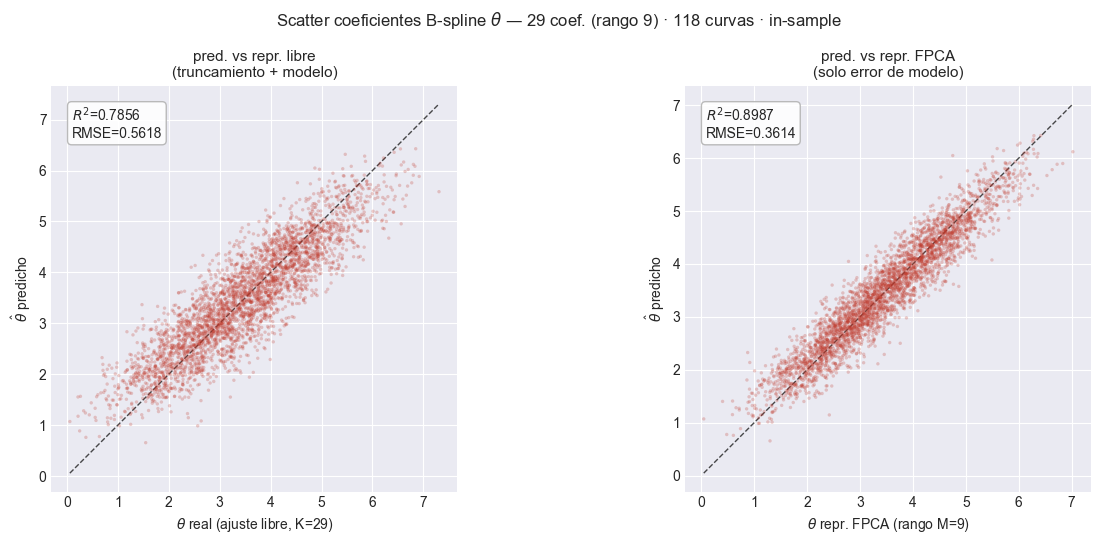

── Scatter θ (in-sample) ────────────────────────────────────────────
  vs $\theta$ real (ajuste libre, K=29)  R²=+0.7856  RMSE=0.561834
  vs $\theta$ repr. FPCA (rango M=9)     R²=+0.8987  RMSE=0.361366


In [15]:
# ── Scatter en espacio de COEFICIENTES B-spline (θ) — in-sample ──────────────
# Complementa §5.1 (que vive en espacio de scores ξ). Aquí la predicción se ve
# en los K=29 coeficientes B-spline, recordando que salen de M=9 scores vía
# scores_to_theta (θ̂ = μθ + ξ̂ Bᵀ): 29 coeficientes en forma, rango efectivo 9.
#
#   Izq.  θ̂_pred  vs  θ_real (ajuste B-spline LIBRE, rango K=29)
#         → la desviación mezcla truncamiento FPCA (29→9) + error de modelo.
#           Se ve el colapso de los coeficientes de orden alto hacia μθ.
#   Der.  θ̂_pred  vs  θ_repr (representación FPCA de los reales, rango M=9)
#         → ambos de rango 9 ⇒ la desviación es SOLO error del modelo PSBP.
if fpca_available and fr is not None:
    # Coeficientes alineados al tramo predicho (T_eff = T − n_lags)
    THETA_real_free = THETA[n_lags:]                    # (T_eff, K) ajuste libre, rango 29
    THETA_repr_fpca = scores_to_theta(SCORES[n_lags:])  # (T_eff, K) repr. FPCA reales, rango 9
    THETA_pred      = scores_to_theta(SCORES_pred_eff)  # (T_eff, K) predicción, rango 9 (== THETA_pred_eff de §5.3)

    def _r2_rmse(x, y):
        x, y = x.ravel(), y.ravel()
        rmse   = float(np.sqrt(np.mean((y - x) ** 2)))
        ss_res = np.sum((y - x) ** 2); ss_tot = np.sum((x - x.mean()) ** 2)
        r2     = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
        return r2, rmse

    pairs = [
        (THETA_real_free, THETA_pred, r"$\theta$ real (ajuste libre, K=29)",
         "pred. vs repr. libre\n(truncamiento + modelo)"),
        (THETA_repr_fpca, THETA_pred, rf"$\theta$ repr. FPCA (rango M={M_fpca})",
         "pred. vs repr. FPCA\n(solo error de modelo)"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    for ax, (x, y, xlabel, subtitle) in zip(axes, pairs):
        lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.7, zorder=1)
        ax.scatter(x.ravel(), y.ravel(), s=6, alpha=0.25,
                   color="#c0392b", edgecolors="none", zorder=2)
        r2, rmse = _r2_rmse(x, y)
        ax.set_title(subtitle, fontsize=11)
        ax.set_xlabel(xlabel); ax.set_ylabel(r"$\hat\theta$ predicho")
        ax.text(0.05, 0.95, f"$R^2$={r2:.4f}\nRMSE={rmse:.4f}",
                transform=ax.transAxes, va="top",
                bbox=dict(boxstyle="round", fc="white", ec="0.7", alpha=0.9))
        ax.set_aspect("equal", adjustable="box")

    fig.suptitle(
        rf"Scatter coeficientes B-spline $\theta$ — {THETA_pred.shape[1]} coef. "
        rf"(rango {M_fpca}) · {THETA_pred.shape[0]} curvas · in-sample",
        fontsize=12,
    )
    fig.tight_layout()
    fig.savefig(PATHS["out_report"] / "23_scatter_theta_coef.png",
                dpi=150, bbox_inches="tight")
    plt.show()

    print("── Scatter θ (in-sample) ────────────────────────────────────────────")
    for x, y, xlabel, _ in pairs:
        r2, rmse = _r2_rmse(x, y)
        print(f"  vs {xlabel:34s}  R²={r2:+.4f}  RMSE={rmse:.6f}")
else:
    print("⚠ fpca_available=False o fr=None — omitiendo scatter de coeficientes.")

### 5.5 Métricas resumen (in-sample)

Con los scores **estandarizados** (var = 1 por componente), los RMSE son
directamente comparables entre componentes — un RMSE de 1 equivale al
predictor trivial $\hat\xi = 0$.

In [16]:
# ── Tabla de métricas por componente (in-sample, escala estandarizada) ───
# [FIX] RMSE comparables entre componentes gracias a la estandarización de
# scores (todas las respuestas tienen var=1).
rows = []
for k in models_chains:
    r = eval_results[k]
    ss_res = np.sum((r["y_obs"] - r["y_hat"]) ** 2)
    ss_tot = np.sum((r["y_obs"] - r["y_obs"].mean()) ** 2)
    r2     = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    corr   = np.corrcoef(r["y_obs"], r["y_hat"])[0, 1]
    rows.append({
        "FPC":  f"FPC {COMPONENT_IDX[k]+1}",
        "RMSE": r["rmse"],
        "R²":   r2,
        "Corr": corr,
        "T_eff": len(r["y_obs"]),
    })

metrics_df = pd.DataFrame(rows).set_index("FPC")
display(
    metrics_df.style
    .format({"RMSE": "{:.6f}", "R²": "{:.4f}", "Corr": "{:.4f}"})
    .background_gradient(subset=["RMSE"], cmap="RdYlGn_r")
    .background_gradient(subset=["R²"],   cmap="RdYlGn",   vmin=0, vmax=1)
    .set_caption("Métricas predictivas por componente FPCA")
)


,RMSE,R²,Corr,T_eff
FPC,,,,
FPC 1,0.105762,0.9886,0.9944,118
FPC 2,0.674707,0.5305,0.7303,118
FPC 3,0.752395,0.4281,0.6573,118
FPC 4,0.821942,0.3109,0.5625,118
FPC 5,0.895090,0.2014,0.4891,118
FPC 6,0.892569,0.2156,0.4660,118
FPC 7,0.970901,0.0655,0.2665,118
FPC 8,0.974136,0.0656,0.2663,118
FPC 9,1.001827,0.0073,0.1706,118
